# **SPECTRA v2**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import torch
import json
import networkx as nx
from matplotlib import pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
from torch_geometric.utils import from_networkx
import os

import warnings
warnings.filterwarnings("ignore")

/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [3]:
# torch device setting
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(torch.version.cuda)
    print(torch.cuda.get_device_name())
else:
    device = torch.device('cpu')
print(device)

12.1
Tesla V100-SXM2-32GB
cuda


In [4]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/michele.calabro/.netrc.
wandb: Currently logged in as: michi-geco97 (michi-geco97-politecn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
# here we put all the hyperparameters, metadata and stuff
config = dict(
    dataset_size=50000,
    test_ratio=0.2,
    val_ratio=0.1,
    batch_size=48,
    n_channels=48,
    edge_dropout_p=0.0,
    lr=0.001,
    n_epochs=20,
    dataset="VCC",
    architecture="DirGCNConv(ChebConv)")

In [6]:
# Initialize wandb run
wandb.init(
    project="spectra-v2",       # The name of your project in wandb
    name="SkipConnections_full_4hops",   # (Optional) Name of this specific run
    config=config               # Pass your dictionary here!
)

### **Data import**

here we try to donalod the replogle raw dataset, but it's a mess

In [4]:
# data loading and filtering
adata = sc.read_h5ad('../data/vcc_data/adata_Training.h5ad') #VCC
#adata = sc.read_h5ad('../data/replogle_k562_essential/perturb_processed.h5ad') # replogle
adata

AnnData object with n_obs × n_vars = 221273 × 18080
    obs: 'target_gene', 'guide_id', 'batch'
    var: 'gene_id'

In [ ]:
# Rename column and ctrl samples
adata.obs = adata.obs.rename(columns={"condition": "target_gene"})
adata.obs["target_gene"] = adata.obs["target_gene"].str.replace("ctrl", "non-targeting", regex=False)

# rename of single perturbations
adata.obs["target_gene"] = adata.obs["target_gene"].str.replace("ctrl", "non-targeting", regex=False)
adata.obs['target_gene'] = adata.obs['target_gene'].str.replace(r'\+non-targeting$', '', regex=True)

adata

AnnData object with n_obs × n_vars = 162751 × 5000
    obs: 'target_gene', 'cell_type', 'cov_drug_dose_name', 'dose_val', 'control', 'condition_name'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'

In [5]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3) # TODO: should be 3 but if so I would have to recalculate the GRN....
adata

AnnData object with n_obs × n_vars = 221273 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'

In [6]:
adata.raw = adata.copy() 
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)

# select only perturbations that are present in at least 200 cells
counts = adata.obs['target_gene'].value_counts()
valid_pert = counts[counts >= 100].index
adata = adata[adata.obs['target_gene'].isin(valid_pert)]
del counts
del valid_pert
adata

View of AnnData object with n_obs × n_vars = 220998 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

### **GRN preparation**

***
### Patrick stuff

In [8]:
# patrick guanlab (stock)
A = np.load('Patrick_networks/guanlab_stock_3.5k_directed.npz')
adjacency = A['adjacency']
gene_names = A['gene_names']

# Create weighted DiGraph (parallel_edges=False treats values as weights)
G = nx.from_numpy_array(
    adjacency,
    parallel_edges=False,
    create_using=nx.DiGraph(),
    edge_attr='weight',  # Attribute name for weights
)

# Relabel nodes with gene names (must be same length as matrix dims)
mapping = {i: gene_names[i] for i in range(len(gene_names))}
G = nx.relabel_nodes(G, mapping)

# naive pruning
G.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if np.log(d['weight']+1) < 8])

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

# filter adata
gene_list = gene_names.tolist()
mask = adata.var_names.isin(gene_names)
adata = adata[:, mask].copy()
adata

Number of nodes: 3406
Number of edges: 474761
Number of node features per node: 1


AnnData object with n_obs × n_vars = 220998 × 3406
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

### End of patrick stuff
***

In [ ]:
# replogle grn

# network file
with open('../SCENIC_GRNs/SCENIC_GRNs/networks/repogle_network.json', 'r') as json_file:
    network = json.load(json_file)
    
# Create the networkx graph
G = nx.DiGraph()
for tf, targets in network.items():
    for target, weight in targets:
        G.add_edge(tf, target, weight=weight)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
gene_list = list(G.nodes)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

# filtering data to gene contained in the network G
adata.var_names = adata.var['gene_name'].astype(str)
adata.var_names_make_unique()
adata = adata[:, adata.var_names.isin(gene_list)]

# perturbation filtering
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')
perts_not_included = [pert for pert in perturbations if not pert in gene_list]
adata = adata[~adata.obs['target_gene'].isin(perts_not_included)].copy()

# adata rows shuffle (otherwise perturbations are all ordered)
adata = adata[np.random.permutation(adata.n_obs), :].copy()
adata

Number of nodes: 3390
Number of edges: 11995
Number of node features per node: 1


AnnData object with n_obs × n_vars = 52525 × 3390
    obs: 'target_gene', 'cell_type', 'cov_drug_dose_name', 'dose_val', 'control', 'condition_name'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'

***

### GRNBoost2 network on 3406 genes

In [ ]:
# load GRN
network_data = pd.read_csv('../SCENIC_GRNs/SCENIC_GRNs/temp_results/adjacencies_vcc_3406.tsv', sep='\t')

# Create the networkx graph
G = nx.DiGraph()
for i in range(network_data.shape[0]):
    edge = network_data.iloc[i,:]
    if np.abs(edge['importance'])>0.0: #TODO: dumb pruning, make somehting better please
        G.add_edge(edge['TF'], edge['target'], weight=edge['importance'])

gene_list = list(G.nodes)

mask = adata.var_names.isin(gene_list)
adata = adata[:, mask].copy()
adata

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)

Number of nodes: 3391
Number of edges: 213388


***

In [9]:
# check if the node names of th enwtrokx graph aorresponds to adata.var_names
assert set(G.nodes) == set(adata.var_names), "Nodes in G and adata.var_names differ!"

In [10]:
# relabel networkx node indices to match the adata
gene_to_idx = {node: i for i, node in enumerate(adata.var_names)}
G = nx.relabel_nodes(G, gene_to_idx)
edge_index = from_networkx(G, group_edge_attrs='all').edge_index # this way, edge_index follows the gene order of adata.var_names

### **Dataloaders preparation**
Compared with the original SPECTRA model, here we should calculate the dataloaders so that in each batch there are only samples taken from the same perturbations.

In [11]:
from torch.utils.data.sampler import Sampler
import random

# a special batch sampler that groups only cells from the same interventional distribution into a batch
class SCDATA_sampler(Sampler):
    def __init__(self, data, batchsize, ptb_name=None):
        self.intervindices = []
        self.len = 0
        if ptb_name is None:
            ptb_name = data.ptb_names

        for ptb in set(ptb_name):
            idx = np.where(ptb_name == ptb)[0] # indices of cells with the same pert ptb
            self.intervindices.append(idx) # list of indices of cells with the same pert ptb
            self.len += len(idx) // batchsize # number of batches with pert ptb
        self.batchsize = batchsize
    
    def __iter__(self):
        comb = []
        # loop over each intervention
        for i in range(len(self.intervindices)):
            random.shuffle(self.intervindices[i]) # intra-Perturbation Shuffle
            interv_batches = chunk(self.intervindices[i], self.batchsize)
            if interv_batches:
                comb += interv_batches

        combined = [batch.tolist() for batch in comb]
        random.shuffle(combined) # shuffle the order of the batches
        return iter(combined)

    def __len__(self):
        return self.len


def chunk(indices, chunk_size):
    split = torch.split(torch.tensor(indices), chunk_size) # this divides the torch indices into subsets of equal length chunk_size
    
    if len(indices) % chunk_size == 0:
        return split
    elif len(split) > 0:
        # If there are some indices left over (the last chunk is smaller than chunk_size),
        # this line discards the last chunk. 
        # It returns all the chunks except the last one.
        return split[:-1]
    else:
        return None

In [12]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class PerturbationDataset(Dataset):
    def __init__(self, adata, gene_to_idx, start_idx=0, end_idx=None, seed=42):
        super().__init__()

        self.edge_index = edge_index.share_memory_()
        self.gene_to_idx = gene_to_idx
        self.start_idx = start_idx
        self.seed = seed
        self.end_idx = end_idx if end_idx is not None else len(adata)

        adata = adata[self.start_idx:self.end_idx].copy()
        self.adata = adata

        # perturbed samples
        ptb_adata = adata[adata.obs['target_gene']!='non-targeting'].copy()
        ptb_samples = ptb_adata.X.toarray() if hasattr(ptb_adata.X, 'toarray') else np.asarray(ptb_adata.X)
        self.ptb_samples = torch.tensor(ptb_samples, dtype=torch.float) #NOTE: local to this split
        self.ptb_names = ptb_adata.obs['target_gene'].values #NOTE: local to this split

        # control samples
        self.ctrl_samples = adata[adata.obs['target_gene']=='non-targeting'].X.copy()
        self.ctrl_samples = self.ctrl_samples.toarray() if hasattr(self.ctrl_samples, 'toarray') else np.asarray(self.ctrl_samples)
        self.ctrl_samples = torch.tensor(self.ctrl_samples, dtype=torch.float)

    def _pert_embedding(self, pert_name):
        embedding = torch.zeros(self.adata.shape[1], dtype=torch.bool)
        perturbs = [self.gene_to_idx[g] for g in pert_name.split('+') if g in self.gene_to_idx]
        for pert in perturbs:
            embedding[pert]=True
        return embedding

    def __getitem__(self, idx):
        
        # Map to actual index in adata
        actual_idx = idx

        #x = self.rand_ctrl_samples[actual_idx].view(-1,1)
        j = np.random.randint(0, self.ctrl_samples.shape[0]) #random control cell
        x = self.ctrl_samples[j].view(-1,1)
        y = self.ptb_samples[actual_idx].view(-1,1)
        pert = self._pert_embedding(self.ptb_names[actual_idx])

        return x,y,pert

    def __len__(self):
        return self.ptb_samples.shape[0]

In [13]:
#TODO: add sanity check for dataset_size (must be inferior than the number of the perturbed cells, see how the sampling works)

# Setup
dataset_size = (adata.obs['target_gene'] != 'non-targeting').sum() #config['dataset_size']
test_ratio = config['test_ratio']
val_ratio = config['val_ratio']
test_size = int(dataset_size * test_ratio)
val_size = int(dataset_size * val_ratio)
train_size = dataset_size - test_size - val_size


# Create datasets
train_dataset = PerturbationDataset(
    adata, gene_to_idx,
    start_idx=0, 
    end_idx=train_size
)

val_dataset = PerturbationDataset(
    adata, gene_to_idx,
    start_idx=train_size, 
    end_idx=train_size+val_size
)

test_dataset = PerturbationDataset(
    adata, gene_to_idx,
    start_idx=train_size+val_size, 
    end_idx=dataset_size
)

N_WORKERS = 4 #TODO this will be passed as an argument to training load dataset
batch_size = config['batch_size']

# create loaders
train_loader = DataLoader(train_dataset, batch_sampler=SCDATA_sampler(train_dataset, batch_size), num_workers=N_WORKERS, pin_memory=True) #pin memory optimize transfer to CUDA
val_loader = DataLoader(val_dataset, batch_sampler=SCDATA_sampler(val_dataset, batch_size), num_workers=N_WORKERS, pin_memory=True) 
test_loader = DataLoader(test_dataset, batch_sampler=SCDATA_sampler(test_dataset, batch_size), num_workers=N_WORKERS, pin_memory=True) 

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 105784
Test dataset size: 30241
Validation dataset size: 15125


**NOTES** about dimensions: `pert` has dimension [B,N], `x` and `y` have dimension [B,N,1]

In [14]:
#NOTE: new DEGs weights
from WMSE import compute_weights

gene_weights = compute_weights(adata[0:train_size,:], gene_to_idx, cells_per_pert=256)

Calculating WMSE Weights: 100%|██████████| 145/145 [00:00<00:00, 1618.67it/s]


### **Model setup**

In [15]:
from spectra_v2_mod import PerturbModel

model = PerturbModel(
    edge_index, 
    num_nodes, 
    device, 
    gene_weights=gene_weights, 
    num_node_features=1, 
    n_channels=config['n_channels'], 
)
model = model.to(device)
print(model)

PerturbModel(
  (ko_mu): Embedding(3406, 64)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.2, inplace=False)
      (1): Linear(in_features=64, out_features=48, bias=True)
      (2): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU()
      (4): Dropout(p=0.2, inplace=False)
      (5): Linear(in_features=48, out_features=48, bias=True)
      (6): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (conv1): DirGNNConv(ChebConv(1, 48, K=3, normalization=sym), alpha=0.5)
    (ln1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
    (conv2): DirGNNConv(ChebConv(48, 96, K=3, normalization=sym), alpha=0.5)
    (ln2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (conv_mu): DirGNNConv(ChebConv(96, 48, K=2, normalization=sym), alpha=0.5)
    (conv_logstd): DirGNNConv(ChebConv(96, 48, K=2, normalization=sym), alpha=0.5)
  )
  (gex_dec

In [49]:
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'number of parameters: {num_trainable_params}')

number of parameters: 249521


In [24]:
#from model_v3_efficient import train
from spectra_v2 import train
_, _, test_wmse = train(model=model, 
    train_loader=train_loader, 
    test_loader=val_loader,
    lr=config['lr'], 
    n_epochs=config['n_epochs'],  
    device=device,
    wandb_support=True,
    live_plot=False)

training at epoch 1:   0%|          | 1/2133 [00:02<1:21:40,  2.30s/it]


KeyboardInterrupt: 

In [ ]:
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/cosine_loss,▁▇██████▇█▇█▇█▇█▇▇▇▇
train/global_loss,█▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁
train/kl_divergence,█▄▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▂▁▁
train/mmd_ctrl,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mmd_pert,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mse,█▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/test_wmse,▁▁▂▃▂▁▄▃▃▃▆▅▅▃▄▃▃███
epoch,20
train/cosine_loss,0.97589
train/global_loss,0.24066


In [ ]:
torch.save(model.state_dict(), "test_25_gen.pth")

***

### **Testing**

In [18]:
model.load_state_dict(torch.load("test_11_mar__chebconv_skipcon.pth"))

<All keys matched successfully>

In [19]:
model.eval()

PerturbModel(
  (ko_mu): Embedding(3406, 64)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.2, inplace=False)
      (1): Linear(in_features=64, out_features=48, bias=True)
      (2): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU()
      (4): Dropout(p=0.2, inplace=False)
      (5): Linear(in_features=48, out_features=48, bias=True)
      (6): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (conv1): DirGNNConv(ChebConv(1, 48, K=3, normalization=sym), alpha=0.5)
    (ln1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
    (conv2): DirGNNConv(ChebConv(48, 96, K=3, normalization=sym), alpha=0.5)
    (ln2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (conv_mu): DirGNNConv(ChebConv(96, 48, K=2, normalization=sym), alpha=0.5)
    (conv_logstd): DirGNNConv(ChebConv(96, 48, K=2, normalization=sym), alpha=0.5)
  )
  (gex_dec

In [20]:
from tqdm import tqdm
from scipy import sparse
import anndata as ad

In [ ]:
# technical duplicates
indices_1 = []
indices_2 = []
for gene, idx in adata.obs.groupby("target_gene").indices.items():
    idx = np.array(idx) # list of indices associated to gene
    half = len(idx) // 2
    indices_1.extend(idx[:half])
    indices_2.extend(idx[half:])
real_adata = adata[indices_1].copy()
pred_adata = adata[indices_2].copy()


/localscratch/29440558.michele.calabro/ipykernel_878365/8321379.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for gene, idx in adata.obs.groupby("target_gene").indices.items():


In [21]:
n_cells = len(test_dataset)
real_adata = adata[-n_cells:, :]
real_adata

View of AnnData object with n_obs × n_vars = 30241 × 3406
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [22]:
n_min_samples = 100
counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= n_min_samples]
gene_counts_dict = counts.drop('non-targeting').to_dict() # creation of dict: for each pertuyrbation how many cells to generate
real_adata = real_adata[real_adata.obs['target_gene'].isin(counts.index)]
real_adata

View of AnnData object with n_obs × n_vars = 27863 × 3406
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [23]:
###### NO TSNE
def generate_adata_from_control(gene_counts_dict, real_adata, model, gene_to_idx, var_names):

    prediction_list = []
    obs_gene_list = []

    # ctrl
    real_adata_control = real_adata[real_adata.obs['target_gene']=='non-targeting']
    ctrl_data = real_adata_control.X.toarray() if hasattr(real_adata_control.X, "toarray") else np.asarray(real_adata_control.X)
    ctrl_data = torch.tensor(ctrl_data, dtype=torch.float)

    for pert, n_samples in tqdm(gene_counts_dict.items()):

        # perturbation one-hot embedding
        pert_embedding = torch.zeros(adata.shape[1], dtype=torch.bool)
        if pert!='non-targeting':
            perturbs = [gene_to_idx[g] for g in pert.split('+') if g in gene_to_idx] #NOTE: this takes into account multi-genes pertrurbations
            for single_pert in perturbs:
                pert_embedding[single_pert]=True
            pert_embedding = pert_embedding.unsqueeze(0)
            
        for i in range(n_samples):
            ctrl_sample = ctrl_data[np.random.randint(0, ctrl_data.shape[0], 1), :].reshape(-1,1).unsqueeze(0)
            data = ctrl_sample, pert_embedding
            predicted_full_gex= model.predict_full_expression(data)
            predicted_full_gex = predicted_full_gex.reshape(1,-1).detach().cpu()
            prediction_list.append(predicted_full_gex.numpy()) 
            obs_gene_list.append(pert)

    X = np.vstack(prediction_list)
    obs = pd.DataFrame({"target_gene": obs_gene_list})
    var = pd.DataFrame(index=var_names)
    pred_adata = ad.AnnData(X=X, obs=obs, var=var)
    
    return pred_adata

In [26]:
####### with TSNE
from sklearn.manifold import TSNE

def generate_adata_from_control(gene_counts_dict, real_adata, model, gene_to_idx, var_names):

    prediction_list = []
    obs_gene_list = []
    latent_representations = []

    real_adata_control = real_adata[real_adata.obs['target_gene']=='non-targeting']
    ctrl_data = real_adata_control.X.toarray() if hasattr(real_adata_control.X, "toarray") else np.asarray(real_adata_control.X)
    ctrl_data = torch.tensor(ctrl_data, dtype=torch.float)

    for pert, n_samples in tqdm(gene_counts_dict.items()):

        # perturbation one-hot embedding
        pert_embedding = torch.zeros(adata.shape[1], dtype=torch.bool)
        if pert!='non-targeting':
            perturbs = [gene_to_idx[g] for g in pert.split('+') if g in gene_to_idx] #NOTE: this takes into account multi-genes pertrurbations
            for single_pert in perturbs:
                pert_embedding[single_pert]=True
            pert_embedding = pert_embedding.unsqueeze(0)
            
        # sampling random control cell
        for i in range(n_samples):
            ctrl_sample = ctrl_data[np.random.randint(0, ctrl_data.shape[0], 1), :].reshape(-1,1).unsqueeze(0)
            data = ctrl_sample, pert_embedding
            predicted_full_gex, z_mean = model.predict_full_expression(data)
            predicted_full_gex = predicted_full_gex.reshape(1,-1).detach().cpu()
            z_mean = z_mean.reshape(1,-1)
            latent_representations.append(z_mean)
            prediction_list.append(predicted_full_gex.numpy()) 
            obs_gene_list.append(pert)

        
    X = np.vstack(prediction_list)
    obs = pd.DataFrame({"target_gene": obs_gene_list})
    var = pd.DataFrame(index=var_names)
    pred_adata = ad.AnnData(X=X, obs=obs, var=var)

    # print('calculating embeddings for the latent space...')
    # latent_complete = np.vstack(latent_representations)
    # embedding_2d = TSNE(n_components=2, init='pca').fit_transform(latent_complete)
    # pred_adata.obsm['X_tsne'] = embedding_2d
    # print('tsne embedding: done')
    
    print('calculating UMAP for the latent space...')
    latent_complete = np.vstack(latent_representations)
    pred_adata.obsm['X_latent'] = latent_complete
    sc.pp.neighbors(pred_adata, use_rep='X_latent', n_neighbors=15, metric='euclidean')
    sc.tl.umap(pred_adata)

    return pred_adata

In [24]:
pred_adata = generate_adata_from_control(gene_counts_dict, real_adata, model, gene_to_idx, real_adata.var_names)
pred_adata

100%|██████████| 104/104 [13:22<00:00,  7.72s/it]


AnnData object with n_obs × n_vars = 22711 × 3406
    obs: 'target_gene'

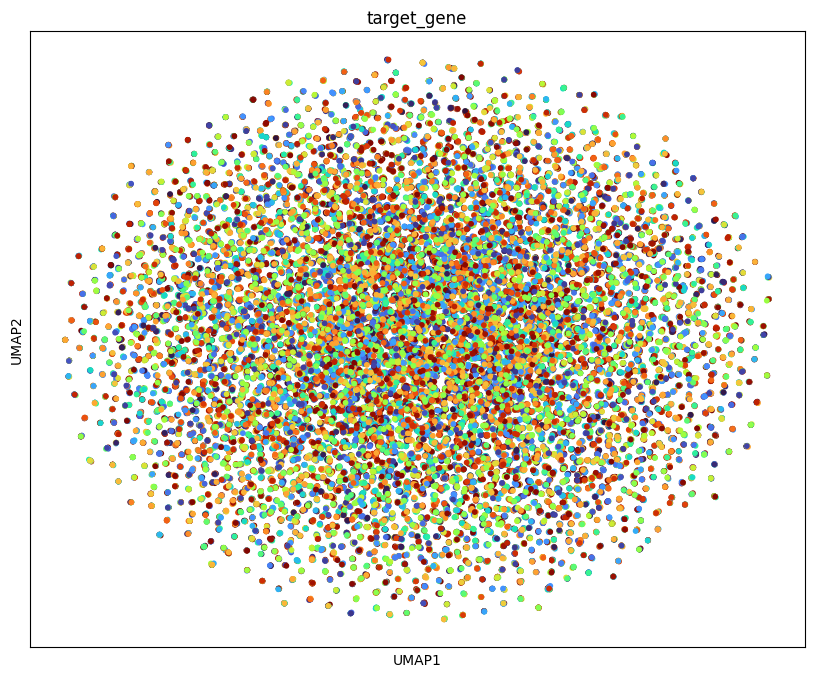

In [ ]:
import matplotlib.colors as mcolors

pred_adata.obs['target_gene'] = pred_adata.obs['target_gene'].astype('category')
num_categories = len(pred_adata.obs['target_gene'].cat.categories)

# We use 'turbo' here, but 'jet' or 'nipy_spectral' are also good for high contrast
rgba_colors = plt.cm.turbo(np.linspace(0, 1, num_categories))
hex_palette = [mcolors.to_hex(c) for c in rgba_colors]
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.umap( #tsne
    pred_adata, 
    color='target_gene', 
    palette=hex_palette,
    size=70,
    # Optional: Turn off the legend if it blocks the view
    legend_loc='none',
    ax = ax
)

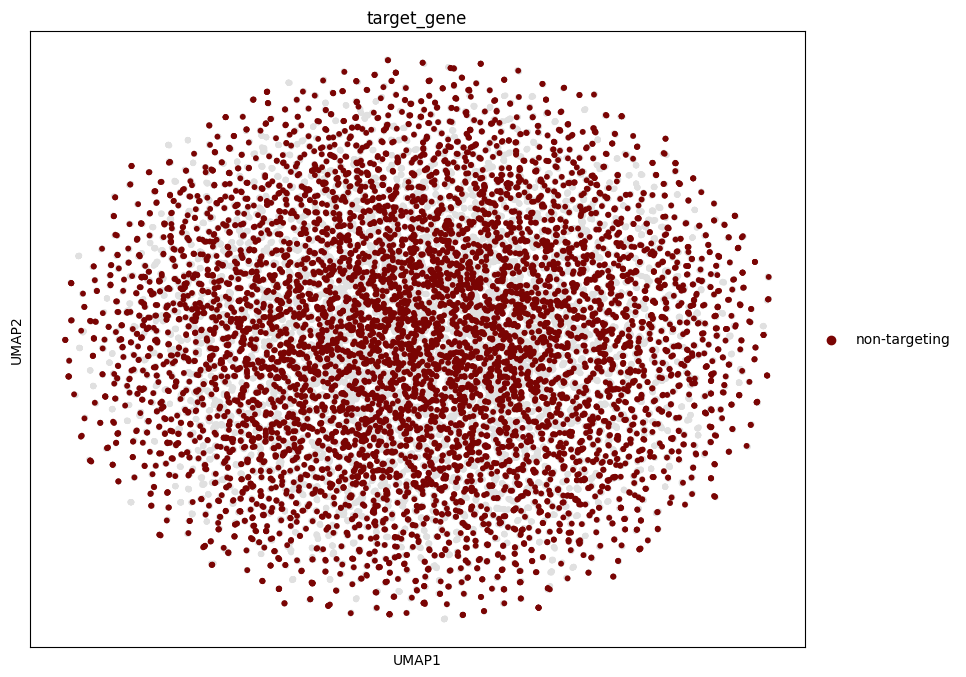

In [ ]:
# Replace 'MY_GENE_NAME' with the specific gene you want to see
gene_to_show = 'non-targeting'

fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.umap(
    pred_adata, 
    color='target_gene', 
    groups=gene_to_show,        # This highlights ONLY this value
    size=70,
    na_color='#e0e0e0',         # Sets the background color (light grey)
    na_in_legend=False,          # Removes the 'NA' entry from the legend
    ax = ax
)

In [26]:
from scores import MAE_error
from scores import corr_error

MAE_error(real_adata, pred_adata)

{'non-targeting': np.float32(0.0), 'POLB': np.float32(0.021488352), 'DAXX': np.float32(0.026274724), 'CAST': np.float32(0.024440812), 'ZNF714': np.float32(0.025753986), 'IKBKG': np.float32(0.026761089), 'WFS1': np.float32(0.020364521), 'MED13L': np.float32(0.022456901), 'SAFB': np.float32(0.034025613), 'IGF2R': np.float32(0.01908449), 'STAT1': np.float32(0.01971814), 'TGFBR2': np.float32(0.035067506), 'NDUFB6': np.float32(0.027883576), 'TET1': np.float32(0.022119313), 'GSK3B': np.float32(0.036627594), 'LAD1': np.float32(0.020999625), 'SOX2': np.float32(0.06676574), 'SMAGP': np.float32(0.031039612), 'ACAT2': np.float32(0.034265168), 'KAT2A': np.float32(0.04948799), 'USP22': np.float32(0.023528747), 'FOXH1': np.float32(0.023715079), 'PBX1': np.float32(0.02066754), 'OXCT1': np.float32(0.033235602), 'TCF3': np.float32(0.022783576), 'DNMT1': np.float32(0.06833318), 'LRPPRC': np.float32(0.03319421), 'CENPO': np.float32(0.023765402), 'EWSR1': np.float32(0.036733486), 'NCK2': np.float32(0.0191

In [31]:
from scores import corr_error

corr_error(real_adata, pred_adata)

{'non-targeting': np.float32(1.0), 'POLB': np.float32(-0.0017906979), 'DAXX': np.float32(0.00018420687), 'CAST': np.float32(0.0031002415), 'ZNF714': np.float32(0.008656715), 'IKBKG': np.float32(-0.005646397), 'WFS1': np.float32(-0.002537997), 'MED13L': np.float32(0.0015255287), 'SAFB': np.float32(-0.001450472), 'IGF2R': np.float32(-0.0003162382), 'STAT1': np.float32(-0.0026627432), 'TGFBR2': np.float32(-0.0027371151), 'NDUFB6': np.float32(0.0038629512), 'TET1': np.float32(0.0023000957), 'GSK3B': np.float32(-0.0020201367), 'LAD1': np.float32(-0.0024368325), 'SOX2': np.float32(0.0052712564), 'SMAGP': np.float32(1.4797744e-06), 'ACAT2': np.float32(0.006811796), 'KAT2A': np.float32(0.0034389799), 'USP22': np.float32(-0.0010338908), 'FOXH1': np.float32(-0.0016993241), 'PBX1': np.float32(0.00015272938), 'OXCT1': np.float32(-0.0058237887), 'TCF3': np.float32(0.00035935405), 'DNMT1': np.float32(-0.0077836895), 'LRPPRC': np.float32(-0.004599258), 'CENPO': np.float32(-0.00124281), 'EWSR1': np.fl

In [31]:
from scores import RobustDES

des_calculator = RobustDES(lfc_threshold=0.5, alpha=0.05)

assert set(real_adata.obs['target_gene'].unique()) == set(pred_adata.obs['target_gene'].unique()), "perturbations do not match"

perts = [pert for pert in real_adata.obs['target_gene'].unique() if pert != 'non-targeting']
scores = {}
for pert in perts:
    scores[pert] = des_calculator.calculate_f1_score(real_adata, pred_adata, 'target_gene', pert, 'non-targeting')
    print(f'score: {scores[pert]}')
    print('---------------------')
global_score = sum(scores.values())/len(scores)
print(f'average score: {global_score}')

pert POLB - n_true = 2, n_pred = 19
score: 0.09523809342403629
---------------------
pert DAXX - n_true = 21, n_pred = 14
score: 0.05714285231020448
---------------------
pert CAST - n_true = 23, n_pred = 18
score: 0.0
---------------------
pert ZNF714 - n_true = 4, n_pred = 21
score: 0.07999999724800008
---------------------
pert IKBKG - n_true = 11, n_pred = 19
score: 0.06666666197777811
---------------------
pert WFS1 - n_true = 3, n_pred = 20
score: 0.08695651939508513
---------------------
pert MED13L - n_true = 15, n_pred = 14
score: 0.06896551219976255
---------------------
pert SAFB - n_true = 100, n_pred = 26
score: 0.01587301259511279
---------------------
pert IGF2R - n_true = 5, n_pred = 18
score: 0.0869565182608697
---------------------
pert STAT1 - n_true = 6, n_pred = 17
score: 0.08695651780718354
---------------------
pert TGFBR2 - n_true = 161, n_pred = 22
score: 0.02185792137955767
---------------------
pert NDUFB6 - n_true = 12, n_pred = 16
score: 0.07142856647959216

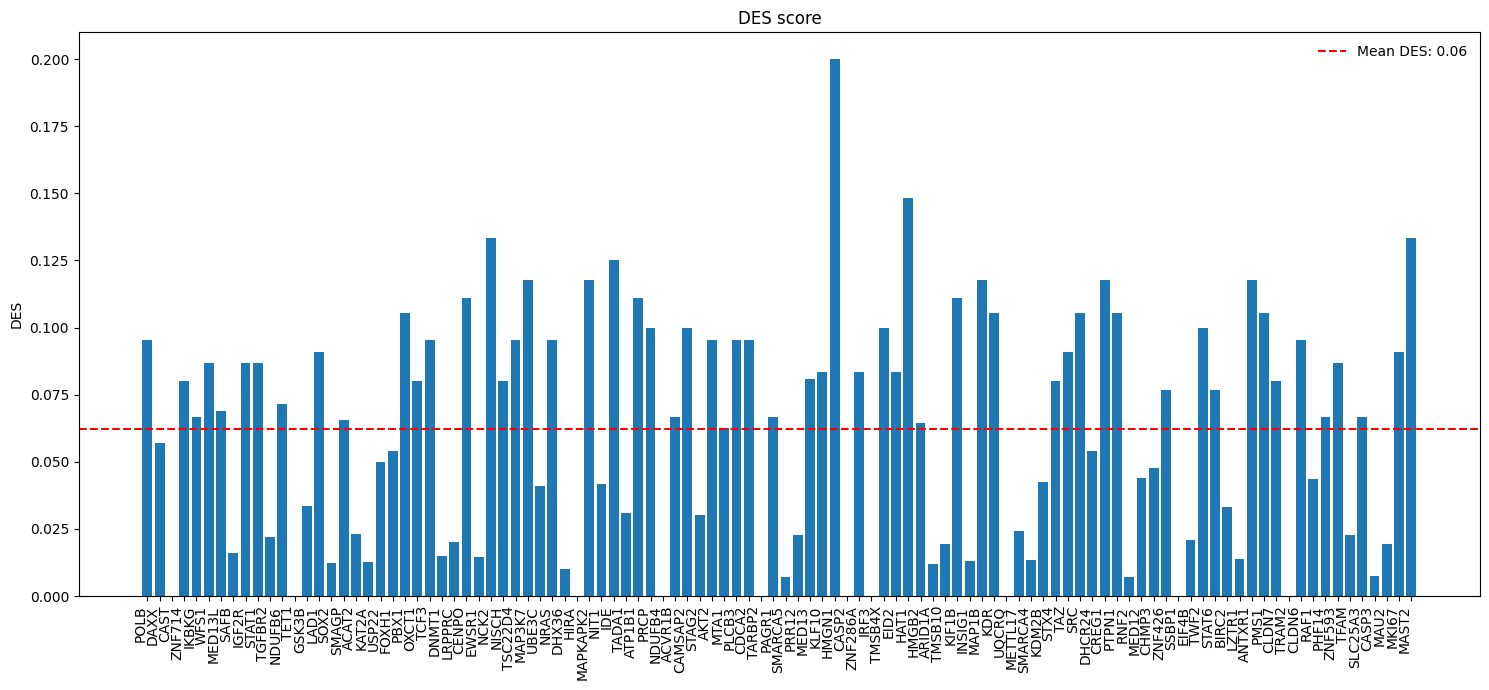

In [32]:
values = list(scores.values())

mean_score = sum(values) / len(values)  # Or use statistics.mean(values)

plt.figure(figsize=(15, 7))
bars = plt.bar(perts, values)#, color='steelblue', alpha=0.7)
plt.xticks(rotation=90, ha='right')  # Vertical labels like your plot
plt.axhline(y=mean_score, color='red', linestyle='--', label=f'Mean DES: {global_score:.2f}')
plt.ylabel('DES')
plt.title('DES score')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

100%|██████████| 104/104 [03:00<00:00,  1.73s/it]


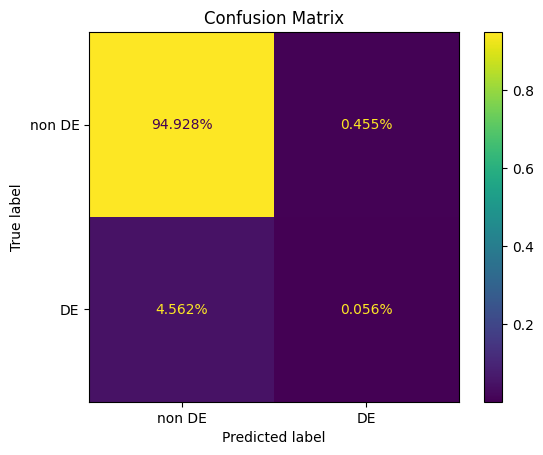

array([[9.49275035e-01, 4.54514657e-03],
       [4.56236732e-02, 5.56145264e-04]])

In [52]:
des_calculator.DES_confusion_matrix(perts,real_adata,pred_adata,'target_gene', 'non-targeting')

In [ ]:
pred_adata.write('results/pred_adata.h5ad')
real_adata.write('results/real_adata.h5ad')

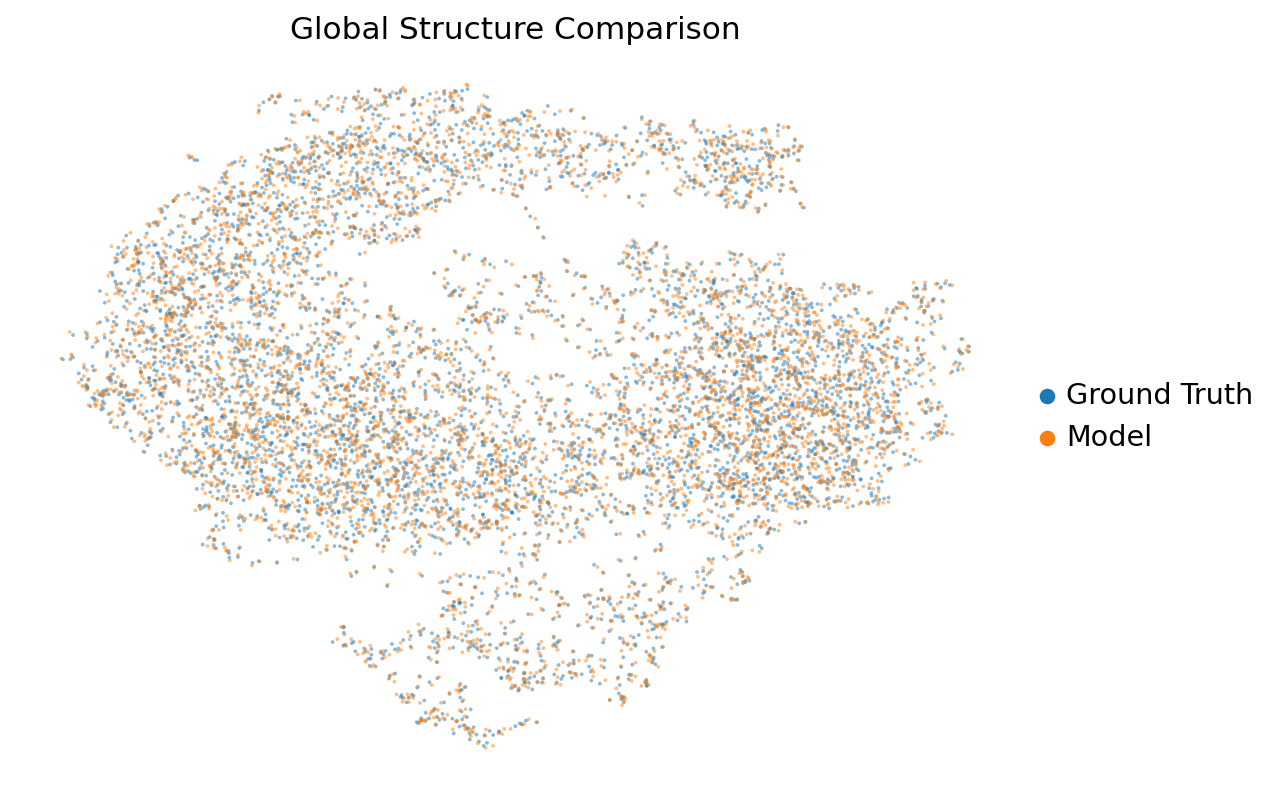

In [79]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Label your datasets
real_adata.obs['dataset'] = 'Ground Truth'
pred_adata.obs['dataset'] = 'Model'

# 2. Concatenate them
adata_combined = real_adata[real_adata.obs['target_gene']=='non-targeting'].concatenate(
    pred_adata[pred_adata.obs['target_gene']=='non-targeting'],
    batch_key='source',
    index_unique='-'
)

# 3. Compute embeddings
sc.pp.pca(adata_combined)
sc.pp.neighbors(adata_combined)
sc.tl.umap(adata_combined)   # <-- FIXED

# 4. Plot
sc.set_figure_params(figsize=(8, 6))
sc.pl.umap(
    adata_combined,
    color=['dataset'],
    alpha=0.5,
    title="Global Structure Comparison",
    frameon = False,
    #save = "umap.pdf"
)


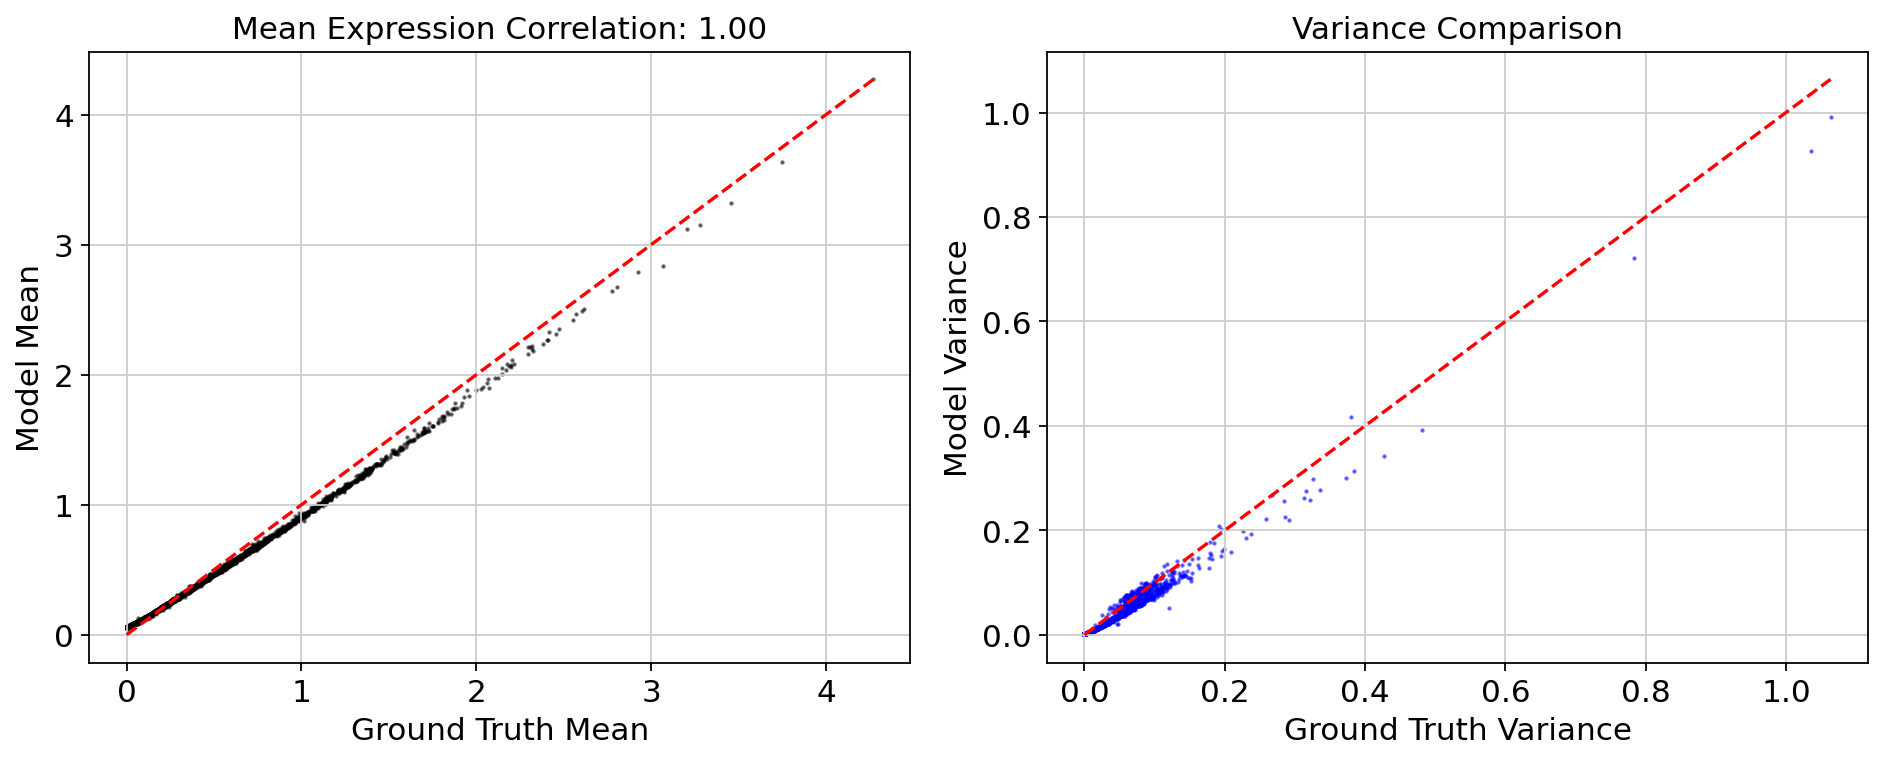

In [ ]:
import numpy as np
import seaborn as sns

# Helper function to get mean expression per gene
def get_gene_metrics(adata):
    # Handle sparse matrices if necessary
    if hasattr(adata.X, "toarray"):
        X = adata.X.toarray()
    else:
        X = adata.X
    
    mean_exp = np.mean(X, axis=0)
    var_exp = np.var(X, axis=0)
    return mean_exp, var_exp

gt_mean, gt_var = get_gene_metrics(real_adata)
model_mean, model_var = get_gene_metrics(pred_adata)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Mean Expression
ax[0].scatter(gt_mean, model_mean, s=1, alpha=0.5, c='k')
ax[0].plot([0, max(gt_mean)], [0, max(gt_mean)], 'r--') # Diagonal
ax[0].set_xlabel("Ground Truth Mean")
ax[0].set_ylabel("Model Mean")
ax[0].set_title(f"Mean Expression Correlation: {np.corrcoef(gt_mean, model_mean)[0,1]:.2f}")

# Plot 2: Variance (Dispersion)
ax[1].scatter(gt_var, model_var, s=1, alpha=0.5, c='b')
ax[1].plot([0, max(gt_var)], [0, max(gt_var)], 'r--') # Diagonal
ax[1].set_xlabel("Ground Truth Variance")
ax[1].set_ylabel("Model Variance")
ax[1].set_title("Variance Comparison")

plt.tight_layout()
plt.show()

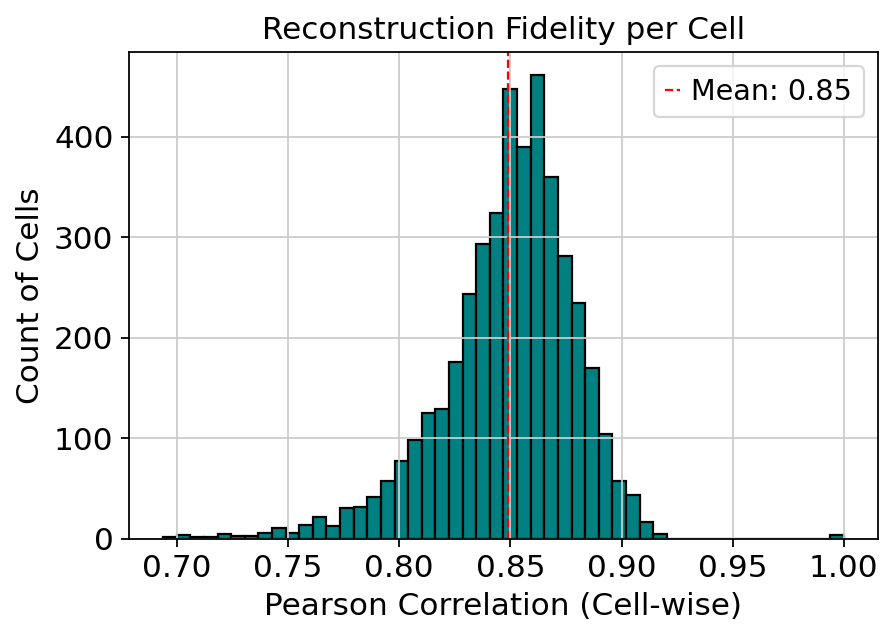

In [ ]:
from scipy.stats import pearsonr

correlations = []
n_cells = pred_adata.shape[0]

# Convert to dense once if memory allows, or iterate carefully
X_gt = real_adata.X if not hasattr(real_adata.X, "toarray") else real_adata.X.toarray()
X_model = pred_adata.X if not hasattr(pred_adata.X, "toarray") else pred_adata.X.toarray()

for i in range(n_cells):
    # Calculate correlation for cell i
    corr, _ = pearsonr(X_gt[i], X_model[i])
    correlations.append(corr)

# Plot Histogram of Correlations
plt.figure(figsize=(6, 4))
plt.hist(correlations, bins=50, color='teal', edgecolor='black')
plt.xlabel("Pearson Correlation (Cell-wise)")
plt.ylabel("Count of Cells")
plt.title("Reconstruction Fidelity per Cell")
plt.axvline(np.mean(correlations), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(correlations):.2f}')
plt.legend()
plt.show()

***

### **Generative model - please work**

In [ ]:
def generate_adata(perts_x_ncells, model, gene_to_idx, var_names):
    prediction_list = []
    obs_gene_list = []

    # for each perturbation....
    for pert in perts_x_ncells.keys():
        if pert != "non-targeting":
            print(pert)

            # how many cells are in the real data and I have to generate with the generative model?
            n_cells = perts_x_ncells[pert]

            # index corresponding to the pert
            ko_gene_idx = gene_to_idx[pert]

            # generate n_cell perturbed cells
            for j in range(n_cells):
                _, predicted_full_gex = model.generative_prediction(ko_gene_idx)
                predicted_full_gex = predicted_full_gex.reshape(1,-1).detach().cpu()
                prediction_list.append(predicted_full_gex.numpy()) 
                obs_gene_list.append(pert)

    # Stack all (1, N) vectors → shape (total_cells, N)
    X = np.vstack(prediction_list)

    # Build obs dataframe
    obs = pd.DataFrame({
        "target_gene": obs_gene_list
    })

    # Build var dataframe (gene names)
    var = pd.DataFrame(index=var_names)   # length N list of gene names

    pred_adata = ad.AnnData(X=X, obs=obs, var=var)
    return pred_adata

In [ ]:
counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= 200]

# Remove 'non-targeting'
gene_counts_dict = counts.drop('non-targeting').to_dict()
del counts

pred_adata2 = generate_adata(gene_counts_dict, model, gene_to_idx, real_adata.var_names)
pred_adata2


In [25]:
# Filter for non-targeting
ntc_adata = real_adata[real_adata.obs["target_gene"] == "non-targeting"]

# Append the non-targeting controls to the example anndata if they're missing
if "non-targeting" not in pred_adata.obs["target_gene"].unique():
    assert np.all(pred_adata.var_names.values == ntc_adata.var_names.values), (
        "Gene-Names are out of order or unequal"
    )
    pred_adata = ad.concat(
        [
            pred_adata,
            ntc_adata,
        ]
    )
del ntc_adata
pred_adata

AnnData object with n_obs × n_vars = 27863 × 3406
    obs: 'target_gene'

In [ ]:
real_adata

View of AnnData object with n_obs × n_vars = 9027 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

***

### Other analysis

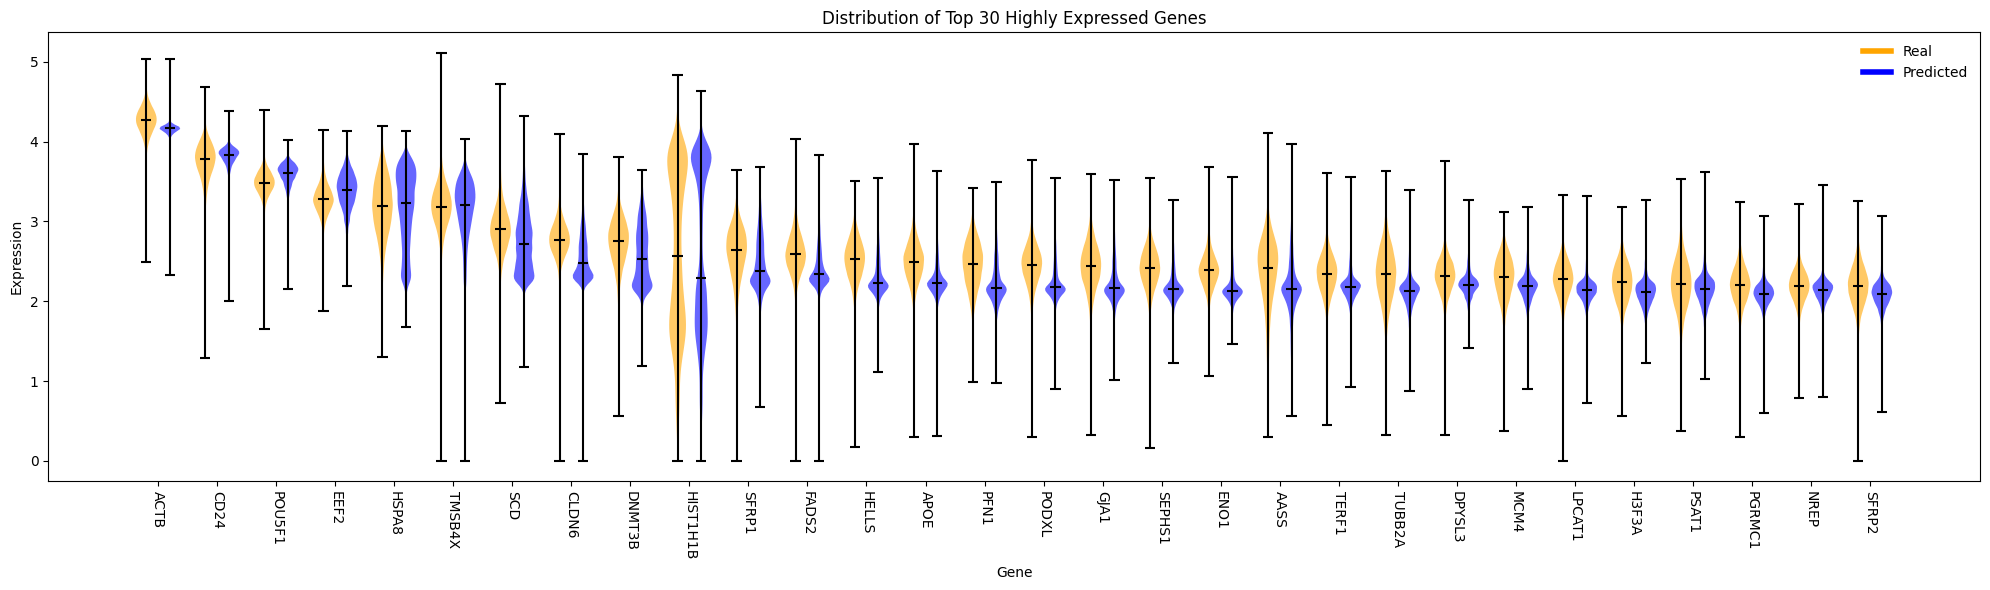

In [38]:
from visualization import plot_top_highly_expressed_genes
from visualization import plot_top_highly_variable_genes

plot_top_highly_expressed_genes(30, real_adata, pred_adata, False)

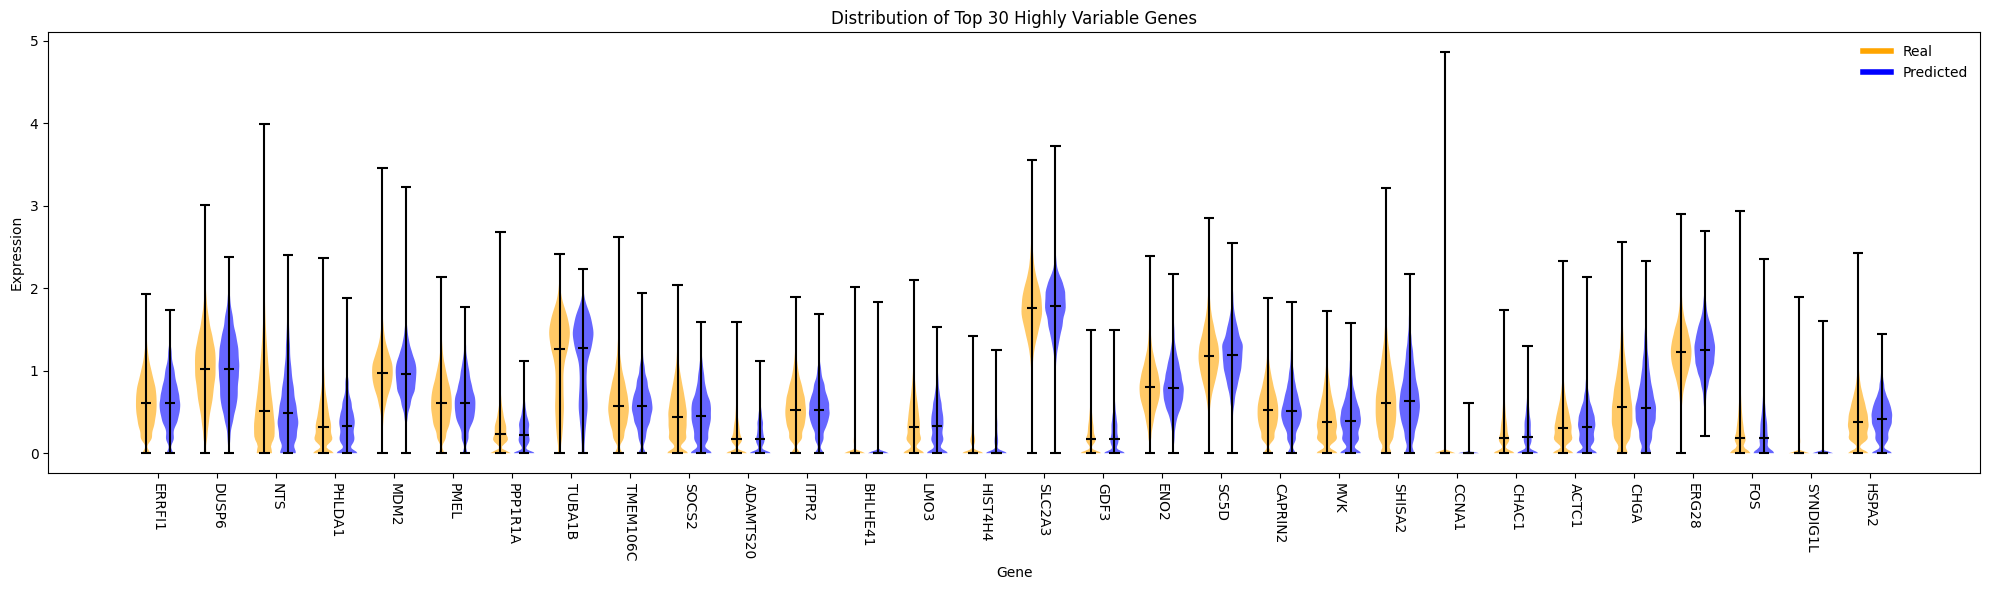

In [39]:
plot_top_highly_variable_genes(30, real_adata, pred_adata, False)

**let's try with just the DE genes**

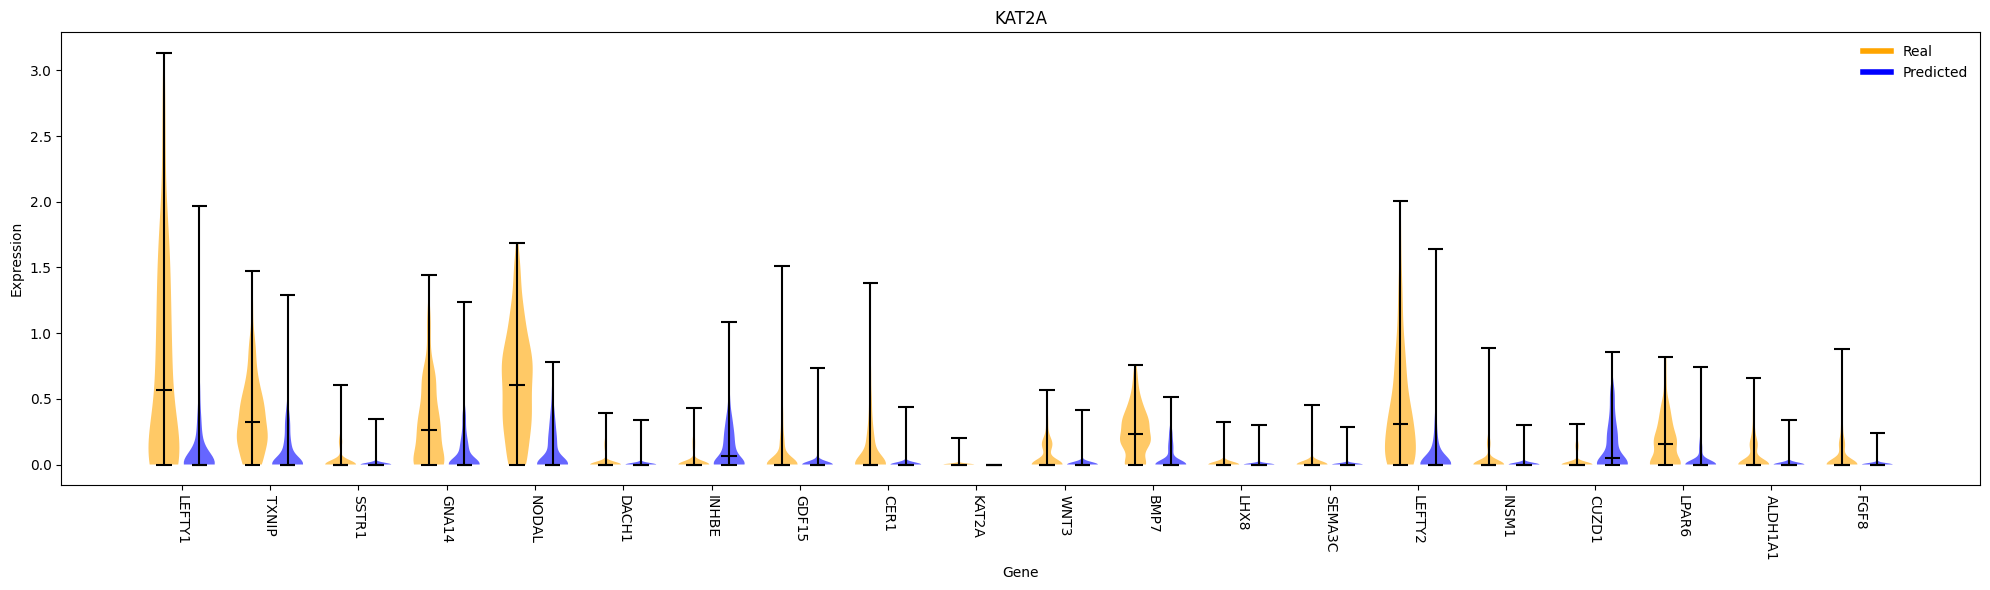

In [40]:
from scores import RobustDES
from visualization import plot_violins_redictions_selected_genes


des_calculator = RobustDES(lfc_threshold=0.5, alpha=0.05)

max_de_genes = 20
perturb_label = 'KAT2A'
DE_genes, _ = des_calculator.get_de_genes(real_adata, 'target_gene', perturb_label, 'non-targeting')
list_DE_genes = list(set(DE_genes.index))
if len(list_DE_genes)>max_de_genes:
    list_DE_genes = list(set(DE_genes.loc[DE_genes['logfoldchanges'].abs().sort_values(ascending=False).index[:max_de_genes]].index))

plot_violins_redictions_selected_genes(list_DE_genes, 
    real_adata[real_adata.obs['target_gene']==perturb_label], 
    pred_adata[pred_adata.obs['target_gene']==perturb_label], 
    False, 
    perturb_label
)


In [43]:
import seaborn as sns
from scipy.stats import wasserstein_distance, pearsonr
from sklearn.metrics import r2_score

In [44]:
def plot_lfc_correlation(real_adata, pred_adata, perturb_list, des_calculator, 
                         target_col='target_gene', ctrl_label='non-targeting', save=False):
    """
    Plots a scatter plot of Real vs Predicted Log2 Fold Changes for DE genes across multiple perturbations.
    """
    all_real_lfcs = []
    all_pred_lfcs = []
    
    # Get the real control cells to serve as the baseline for predicted LFC
    real_ctrl_adata = real_adata[real_adata.obs[target_col] == ctrl_label]
    
    for perturb in perturb_list:
        # 1. Get Real DE genes and their Real LFCs
        de_df, _ = des_calculator.get_de_genes(real_adata, target_col, perturb, ctrl_label)
        if de_df.empty:
            continue
            
        de_genes = de_df.index.tolist()
        real_lfc = de_df['logfoldchanges'].values
        
        # 2. Calculate Predicted LFCs for these specific DE genes
        pred_perturb_adata = pred_adata[pred_adata.obs[target_col] == perturb]
        
        # Extract matrices
        pred_X = pred_perturb_adata[:, de_genes].X
        ctrl_X = real_ctrl_adata[:, de_genes].X
        
        if hasattr(pred_X, "toarray"): pred_X = pred_X.toarray()
        if hasattr(ctrl_X, "toarray"): ctrl_X = ctrl_X.toarray()
            
        # Means per gene (add small pseudocount to avoid log(0))
        mean_pred = pred_X.mean(axis=0) + 1e-9
        mean_ctrl = ctrl_X.mean(axis=0) + 1e-9
        
        # Log2 fold change: log2(Predicted Perturb / Real Control)
        pred_lfc = np.log2(mean_pred / mean_ctrl)
        
        all_real_lfcs.extend(real_lfc)
        all_pred_lfcs.extend(pred_lfc)
        
    # Calculate global Pearson correlation
    r_val, p_val = pearsonr(all_real_lfcs, all_pred_lfcs)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.scatterplot(x=all_real_lfcs, y=all_pred_lfcs, alpha=0.5, s=10, edgecolor=None, color='#1f77b4', ax=ax)
    
    # Plot identity line (y = x)
    min_val = min(min(all_real_lfcs), min(all_pred_lfcs))
    max_val = max(max(all_real_lfcs), max(all_pred_lfcs))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=0.5, label='Perfect Prediction (y=x)')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_xlabel('Ground Truth LFC (Real Perturbed vs Real Control)')
    ax.set_ylabel('Predicted LFC (Pred Perturbed vs Real Control)')
    ax.set_title(f'Global LFC Correlation\nPearson R = {r_val:.3f} (p={p_val:.2e})')
    ax.legend(frameon=False)
    
    sns.despine()
    plt.tight_layout()
    
    if save:
        fig.savefig('LFC_Correlation_Plot.pdf')
    plt.show()

In [45]:
def plot_wasserstein_distances(real_adata, pred_adata, perturb_list, des_calculator, 
                               target_col='target_gene', ctrl_label='non-targeting', save=False):
    """
    Calculates the average Wasserstein distance of DE genes between real and predicted cells for each perturbation.
    """
    perturb_distances = {}
    
    for perturb in perturb_list:
        de_df, _ = des_calculator.get_de_genes(real_adata, target_col, perturb, ctrl_label)
        if de_df.empty:
            continue
            
        de_genes = de_df.index.tolist()
        
        # Isolate the cells for this specific perturbation
        real_vals = real_adata[real_adata.obs[target_col] == perturb, de_genes].X
        pred_vals = pred_adata[pred_adata.obs[target_col] == perturb, de_genes].X
        
        if hasattr(real_vals, "toarray"): real_vals = real_vals.toarray()
        if hasattr(pred_vals, "toarray"): pred_vals = pred_vals.toarray()
            
        # Calculate Wasserstein distance for each gene independently
        w_dists = [wasserstein_distance(real_vals[:, i], pred_vals[:, i]) for i in range(len(de_genes))]
        
        # Store the average distance for this perturbation
        perturb_distances[perturb] = np.mean(w_dists)
        
    # Convert to DataFrame for easy Seaborn plotting and sorting
    df_dists = pd.DataFrame(list(perturb_distances.items()), columns=['Perturbation', 'Avg_Wasserstein_Distance'])
    df_dists = df_dists.sort_values('Avg_Wasserstein_Distance', ascending=False) # Highest distance = worst prediction
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df_dists, x='Perturbation', y='Avg_Wasserstein_Distance', color='salmon', ax=ax)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_ylabel('Average Wasserstein Distance (Lower is better)')
    ax.set_xlabel('Perturbations')
    ax.set_title('Distribution Match between Real and Predicted Perturbations')
    
    sns.despine()
    plt.tight_layout()
    
    if save:
        fig.savefig('Wasserstein_Distances.pdf')
    plt.show()

In [46]:
def plot_delta_mean_r2(real_adata, pred_adata, perturb_list, des_calculator, 
                       target_col='target_gene', ctrl_label='non-targeting', save=False):
    """
    Calculates the R-squared score between the real and predicted *change in mean expression* (Delta) of DE genes relative to the control state.
    """
    perturb_r2 = {}
    
    # Baseline: Real control cells
    real_ctrl_adata = real_adata[real_adata.obs[target_col] == ctrl_label]
    
    for perturb in perturb_list:
        de_df, _ = des_calculator.get_de_genes(real_adata, target_col, perturb, ctrl_label)
        
        # R2 score requires at least 2 genes to compute variance.
        if de_df.empty or len(de_df) < 2:
            continue
            
        de_genes = de_df.index.tolist()
        
        # Isolate matrices
        real_perturb_X = real_adata[real_adata.obs[target_col] == perturb, de_genes].X
        pred_perturb_X = pred_adata[pred_adata.obs[target_col] == perturb, de_genes].X
        real_ctrl_X = real_ctrl_adata[:, de_genes].X
        
        if hasattr(real_perturb_X, "toarray"): real_perturb_X = real_perturb_X.toarray()
        if hasattr(pred_perturb_X, "toarray"): pred_perturb_X = pred_perturb_X.toarray()
        if hasattr(real_ctrl_X, "toarray"): real_ctrl_X = real_ctrl_X.toarray()
        
        # Calculate means
        real_perturb_means = real_perturb_X.mean(axis=0)
        pred_perturb_means = pred_perturb_X.mean(axis=0)
        real_ctrl_means = real_ctrl_X.mean(axis=0)
        
        # CALCULATE DELTAS (Effect Size)
        real_delta = real_perturb_means - real_ctrl_means
        pred_delta = pred_perturb_means - real_ctrl_means
        
        # Calculate R-squared score on the deltas
        r2 = r2_score(real_delta, pred_delta)
        perturb_r2[perturb] = r2
        
    # Convert to DataFrame
    df_r2 = pd.DataFrame(list(perturb_r2.items()), columns=['Perturbation', 'R2_Score_of_Delta'])
    df_r2 = df_r2.sort_values('R2_Score_of_Delta', ascending=False)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df_r2, x='Perturbation', y='R2_Score_of_Delta', color='mediumseagreen', ax=ax)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_ylabel('$R^2$ Score of Delta (Higher is better)')
    ax.set_xlabel('Perturbations')
    ax.set_title('$R^2$ of Perturbation Effect (Delta) per Perturbation')
    ax.axhline(0, color='black', lw=1) # Baseline at 0 (worse than 0 means predicting the mean delta is better)
    
    sns.despine()
    plt.tight_layout()
    
    if save:
        fig.savefig('Delta_R2_Scores.pdf')
    plt.show()

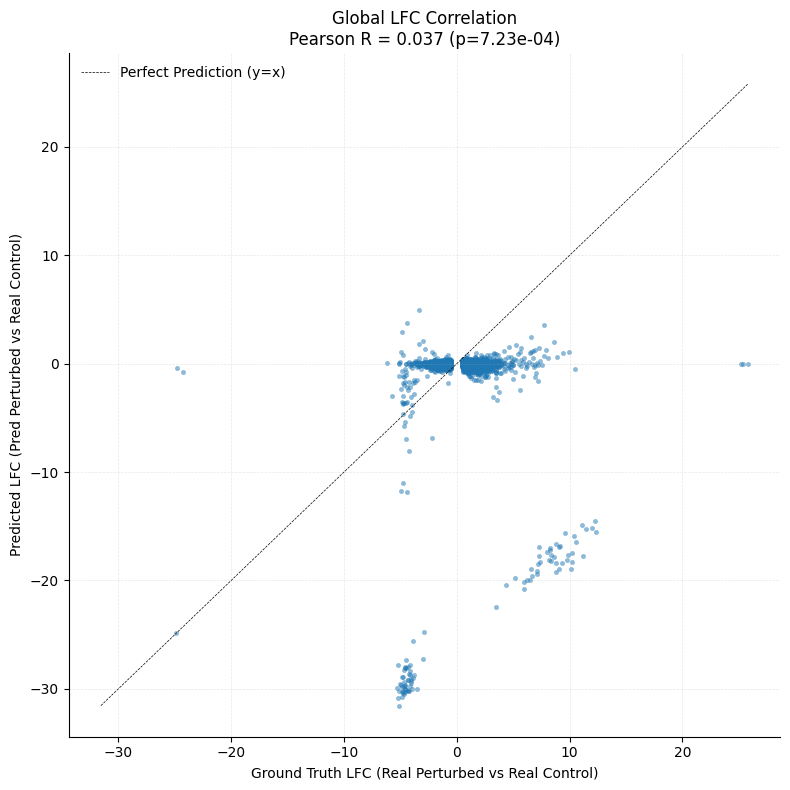

In [47]:
# Remove the control label from your perturbation list so we don't calculate DE for control vs control
perturb_list = [p for p in real_adata.obs['target_gene'].unique() if p != 'non-targeting']

# Option A: Plot Global LFC Scatter
plot_lfc_correlation(real_adata, pred_adata, perturb_list, des_calculator, save=False)


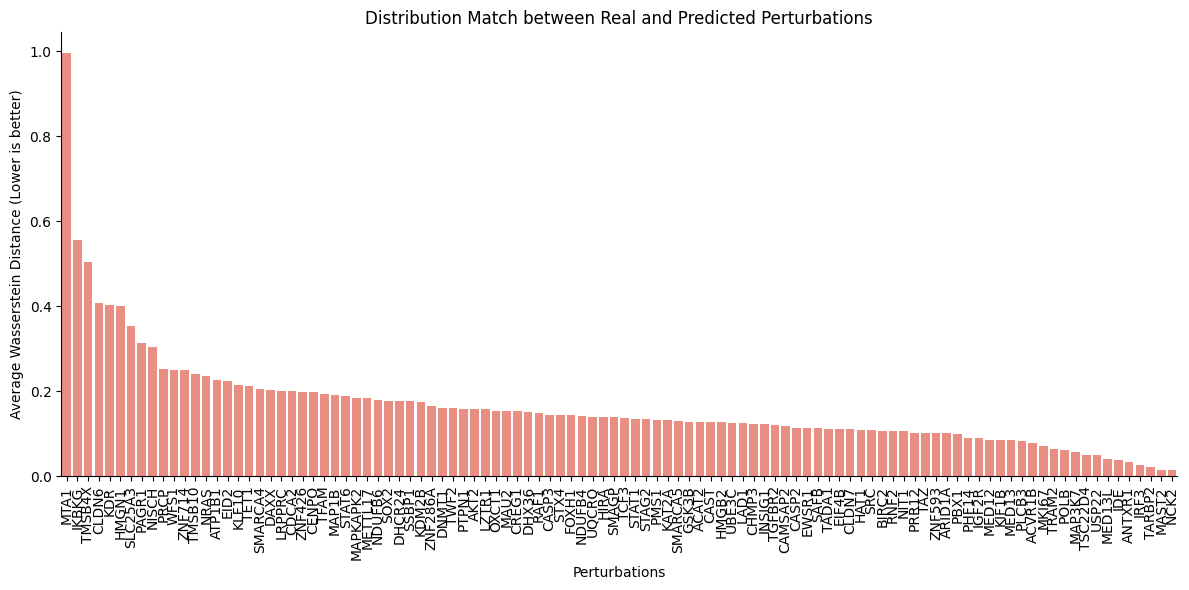

In [48]:

# Option B: Plot Wasserstein Distance Bar Chart
plot_wasserstein_distances(real_adata, pred_adata, perturb_list, des_calculator, save=False)


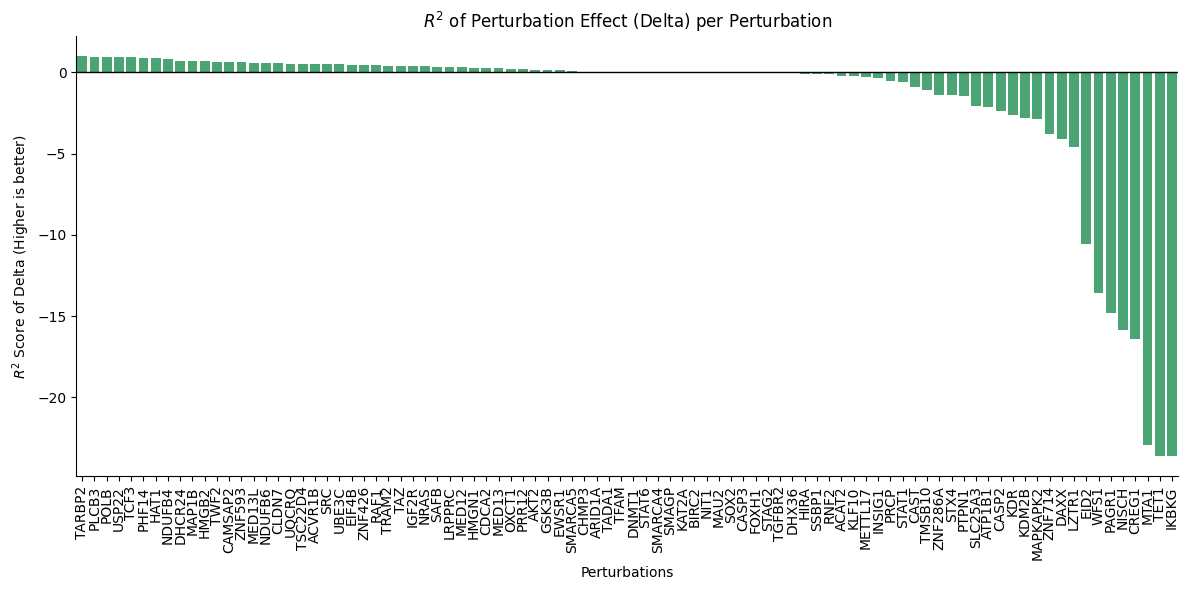

In [49]:
# Option C: Plot R2 Bar Chart
plot_delta_mean_r2(real_adata, pred_adata, perturb_list, des_calculator, save=False)